# **Module 05 Lab02: Model Evaluation and Refinement - Laptop Pricing**

CISC7204 Assgn01 - Lab02 (Laptop Pricing) / Module 06 Final (House Pricing) | mc660725 Gao Si Han

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("laptop_mod2.csv", header=0)
df.drop(['Unnamed: 0','Unnamed: 0.1'], axis=1, inplace=True, errors='ignore')
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


### Task 1: Using cross-validation to improve the model

In [3]:
features = ['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']
x_data = df[features]
y_data = df['Price']

In [4]:
lrm = LinearRegression()
scores = cross_val_score(lrm, x_data, y_data, cv=3)
print('Cross-validation R^2 scores:', scores)
print('Mean CV R^2:', scores.mean())

Cross-validation R^2 scores: [0.16414118 0.46452997 0.40359823]
Mean CV R^2: 0.3440897960492531


### Task 2: Overfitting - split 50% test / 50% train, polynomial degree

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.5, random_state=0)
print('train samples:', x_train.shape[0], 'test samples:', x_test.shape[0])

train samples: 119 test samples: 119


In [6]:
rsqu_test=[]; order=[1,2,3,4,5,6,7]
for n in order:
    pr = PolynomialFeatures(degree=n)
    x_train_pr = pr.fit_transform(x_train[features])
    x_test_pr = pr.transform(x_test[features])
    lr = LinearRegression().fit(x_train_pr, y_train)
    rsqu_test.append(lr.score(x_test_pr, y_test))
print('R^2 test per degree:', dict(zip(order, np.round(rsqu_test,4))))

R^2 test per degree: {1: np.float64(0.3561), 2: np.float64(0.3516), 3: np.float64(0.3317), 4: np.float64(0.3303), 5: np.float64(0.2944), 6: np.float64(0.3206), 7: np.float64(0.3244)}


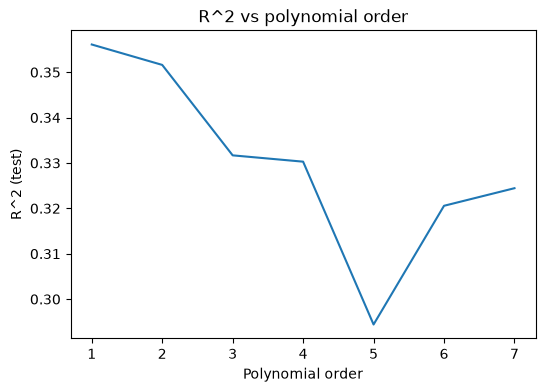

In [7]:
plt.figure(figsize=(6,4))
plt.plot(order, rsqu_test)
plt.xlabel('Polynomial order')
plt.ylabel('R^2 (test)')
plt.title('R^2 vs polynomial order')
plt.show()

### Task 3: Ridge Regression - degree=2 polynomial, multiple features

In [8]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train[features])
x_test_pr = pr.transform(x_test[features])
RidgeModel = Ridge(alpha=0.1).fit(x_train_pr, y_train)
print('Ridge (alpha=0.1) test R^2:', RidgeModel.score(x_test_pr, y_test))

Ridge (alpha=0.1) test R^2: 0.40187612427029273


### Task 4: Grid Search for best alpha among {0.0001,0.001,0.01,0.1,1,10}

In [9]:
Grid = [{'alpha':[0.0001,0.001,0.01,0.1,1,10]}]
grid = GridSearchCV(Ridge(), Grid, cv=3)
grid.fit(x_train_pr, y_train)
print('Best alpha:', grid.best_estimator_.alpha)
print('Best CV score:', grid.best_score_)
print('Test R^2 with best alpha:', grid.score(x_test_pr, y_test))

Best alpha: 10
Best CV score: 0.5106321950567798
Test R^2 with best alpha: 0.422367964654465


# Module 05 complete.